# Flash Drought Detection

In this notebook, we will apply the technique we learned in the previous part to a new case study in South Africa in 2024 and determine its predictive skill as an early warning of drought. In particular, we will apply a "detection rule" to thje time series of SIF-RCI and SWDI to see when our data would indicate a developing flash drought. The "detection rule" is based on two primary values that are chosen subjectively:

* The **drought severity**: a threshold value below which we declare a drought
* The **speed of drought development**: the length of time that an indicator changes from normal/mild to severe anomaly is a distinguishing factor for flash drought

In [3]:
import os

from download import download_unpack_gosif
from tqdm.notebook import tqdm

# For the South Africa case study, we will download data from September 2023 (just before the spring planting) through to
# May 2024 (after the harvest)
years = [2022, 2023]
doy_range = [(years[0], doy_2023) for doy_2023 in range(249, 365, 8)]
doy_range.extend([(years[1], doy_2024) for doy_2024 in range(1, 153, 8)])

output_dir = "data/gosif"
os.makedirs(output_dir, exist_ok=True)

gosif_geotiffs: list[str] = []
for year, doy in tqdm(doy_range, desc="Downloading granules"):
    fname = download_unpack_gosif(
        year,
        day=doy,
        output_dir=output_dir,
        verbose=False
    )
    if fname:
        gosif_geotiffs.append(fname)

In [ ]:
from analysis import compute_sif_time_series, compute_swdi_timeseries

# Set the filename to use for the time series
year_str = '_'.join([str(y) for y in years])
sif_time_series_fname = f"south_africa_{year_str}_sif.csv"
swdi_time_series_fname = f"south_africa_{year_str}_swdi.csv"
# Get the climatology inputs produced by the appendix notebook
clim_dir = "inputs/sif_increments_south_africa/"

# Free State South Africa region of interest
# 28.00°–29.00°S, 27.00°–28.50°E
west, south, east, north = 27, -29.0, 28.5, -28.0

start_date = "2023-09-01"
stop_date = "2024-08-31"

sif_csv_path, n_dates = compute_sif_time_series(
    gosif_geotiffs,
    clim_dir,
    sif_time_series_fname,
    west, south, east, north,
)

swdi_csv_path = compute_swdi_timeseries(
    start_date,
    stop_date,
    swdi_time_series_fname,
    (west, south, east, north),
)

print(f"SIF: Computed time series values for {n_dates} granules and saved to {sif_csv_path}")
print(f"SWDI: Saved time series values to {swdi_csv_path}")

Computed time series values for 33 granules and saved to data/south_africa_2022_2023_sif.csv


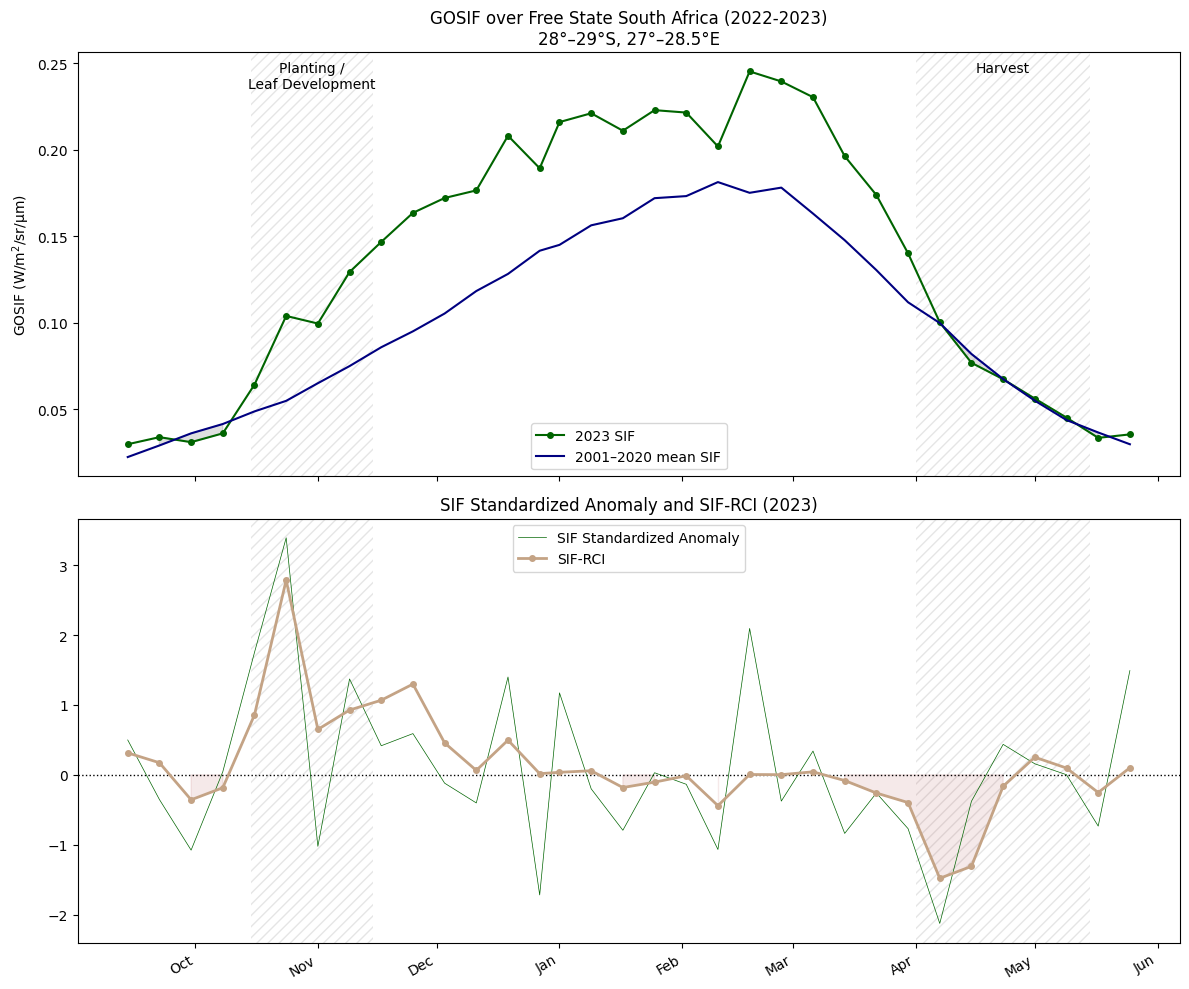

In [ ]:
import csv
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

# Read the saved CSV
plot_dates = []
plot_zscore: list[float] = []
plot_sifrci: list[float] = []

with open(sif_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        plot_zscore.append(float(row["zscore"]))
        plot_sifrci.append(float(row["sif_rci"]))

plot2_swdi: list[float] = []
with open(swdi_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        # Our time series of SWDI is slightly longer, so skip dates that aren't
        # in the SIF time series
        if pt_date not in plot_dates:
            continue
        plot2_swdi.append(float(row["swdi"]))


# As before, we will highlight the period where the SIF-RCI signal
# was persistently below 0
flash_drought = [r < -0.05 for r in plot2_sifrci]

# Typical crop calendar for Maize (Corn) in Free State South Africa:
#   Planting: October 15 – November 15
#   Harvest:  April 1 – May 15
planting_start, planting_end = datetime(years[0], 10, 15), datetime(years[0], 11, 15) # noqa: DTZ001
harvest_start, harvest_end = datetime(years[1], 4, 1), datetime(year, 5, 15) # noqa: DTZ001


def add_crop_calendar(ax: plt.Axes, label: bool = True) -> None:
    """Cross-hatch the usual planting and harvest windows and label them on the plot."""
    ax.axvspan(planting_start, planting_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    ax.axvspan(harvest_start, harvest_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    if label:
        # x in data coordinates, y in axes-fraction coordinates
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(planting_start + (planting_end - planting_start) / 2, 0.98, # type: ignore
                "Planting /\nLeaf Development", transform=trans, ha="center",
                va="top", fontsize=10, color="black")
        ax.text(harvest_start + (harvest_end - harvest_start) / 2, 0.98, # type: ignore
                "Harvest", transform=trans, ha="center", va="top",
                fontsize=10, color="black")


# Plot the time series as two stacked subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Shade the crop calendar behind both subplots (labelled on the top subplot only)
add_crop_calendar(ax1)
add_crop_calendar(ax2, label=False)

# First subplot: SIF vs. climatological mean
ax1.plot(plot_dates, plot_sif, marker="o", color="darkgreen", linewidth=1.5, markersize=4, label=f"{year} SIF")
ax1.plot(plot_dates, plot_mean_sif, color=(0, 0, 0.5), linewidth=1.5, label="2001–2020 mean SIF")
ax1.fill_between(plot_dates, plot_sif, plot_mean_sif, where=below_mean, color="grey", alpha=0.25) #, label="Below mean")
ax1.set_ylabel("GOSIF (W/m$^2$/sr/μm)")
ax1.set_title(f"GOSIF over Free State South Africa ({years[0]}-{years[1]})\n28°–29°S, 27°–28.5°E")
ax1.legend()

# Second subplot: SIF Standardized Anomaly (z-score) and SIF-RCI
ax2.axhline(0, color="black", linestyle=":", linewidth=1)
ax2.plot(plot_dates, plot2_zscore, color="darkgreen", linewidth=0.5, label="SIF Standardized Anomaly")
ax2.plot(plot_dates, plot2_sifrci, marker="o", color=(0.77, 0.64, 0.52), linewidth=2, markersize=4, label="SIF-RCI")
ax2.fill_between(plot_dates, plot2_sifrci, 0, where=flash_drought, color="brown", alpha=0.1)
ax2.set_title(f"SIF Standardized Anomaly and SIF-RCI ({year})")
ax2.legend()

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()